In [1]:
from datasets import load_dataset

ds = load_dataset("uqa/UQA") # splits : train , validation
print (ds)

ex = ds["train"][0]
print(ex.keys()) # id , title , context , question, answers
print(ex["question"])
print(ex["answer"]) # { ’ text ’: [...] , ’ answer_start ’: [...]}
n_total = len(ds["train"])
n_ans = sum(len(a.strip()) > 0 for a in ds["train"]["answer"])
print(f"train rowssssss: {n_total}, answerable: {n_ans}")

README.md:   0%|          | 0.00/898 [00:00<?, ?B/s]

data/train-00000-of-00001-bac007e8ca7192(…): reconstructing file:   0%|          |  0.00B / 30.2MB            

data/train-00000-of-00001-bac007e8ca7192(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-cf8a6960d(…): reconstructing file:   0%|          |  0.00B / 2.92MB            

data/validation-00000-of-00001-cf8a6960d(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/124745 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16824 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})
dict_keys(['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'])
بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
1990 کی دہائی کے آخر میں
train rowssssss: 124745, answerable: 83018


In [2]:
import csv

ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"

# Urdu full stop U+06D4, Urdu question mark U+061F, exclamation mark
SENT_DELIMS = "\u06D4\u061F!"

def split_sentences(text):
    """Yield (start, end, sentence) with offsets into text."""
    start = 0

    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start:i + 1]
            start = i + 1

    if start < len(text):
        yield start, len(text), text[start:]


def make_pair(example, max_src=60, max_tgt=25):
    """Return (source, target) or None if the row is unusable."""

    answer = example["answer"]
    a_start = example["answer_start"]

    if not answer or len(answer.strip()) == 0:
        return None

    a_text = answer
    a_end = a_start + len(a_text)

    context = example["context"]

    for s, e, sent in split_sentences(context):

        if s <= a_start < e:
            rel = a_start - s  # offset inside the sentence

            if sent[rel:rel + len(a_text)] != a_text:
                return None  # offset mismatch -> skip

            src = (
                sent[:rel]
                + " "
                + ANS_OPEN
                + " "
                + a_text
                + " "
                + ANS_CLOSE
                + " "
                + sent[rel + len(a_text):]
            ).strip()

            src = " ".join(src.split())  # normalize whitespace
            tgt = " ".join(example["question"].split())

            if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
                return None

            return src, tgt

    return None


def build_split(split, out_path):
    pairs = [p for p in map(make_pair, split) if p is not None]

    with open(out_path, "w", encoding="utf-8", newline="") as f:
        w = csv.writer(
            f,
            delimiter="\t",
            quoting=csv.QUOTE_NONE,
            escapechar="\\"
        )

        w.writerows(pairs)

    print(f"{out_path}: {len(pairs)} pairs")
    return pairs


train_pairs = build_split(ds["train"], "train.tsv")
valid_pairs = build_split(ds["validation"], "valid.tsv")

train.tsv: 75067 pairs
valid.tsv: 10018 pairs


In [3]:
import sentencepiece as spm

# One line per sentence: sources and targets from the TRAIN split only
with open("sp_corpus.txt", "w", encoding="utf-8") as f:
    for src, tgt in train_pairs:
        f.write(src + "\n" + tgt + "\n")



In [4]:
spm.SentencePieceTrainer.train(
    input="sp_corpus.txt",
    model_prefix="ur_sp",
    vocab_size=8000,
    model_type="unigram",
    character_coverage=1.0,  # keep every Urdu character
    user_defined_symbols=[ANS_OPEN, ANS_CLOSE],
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
)

sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
PAD, UNK, BOS, EOS = 0, 1, 2, 3

src, tgt = train_pairs[0]

print(sp.encode(src, out_type=str))  # pieces
print(sp.encode(tgt))                 # ids
print(sp.decode(sp.encode(tgt)) == tgt)  # round-trip check

['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پرورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابلوں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گر', 'ل', '▁گروپ', '▁ڈسٹنی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']
[2757, 18, 83, 2810, 100, 151, 99, 9, 11]
True


In [5]:
# Show five tokenized examples
for i, (src, tgt) in enumerate(train_pairs[:5], start=1):
    print(f"\nExample {i}")

    print("Source:")
    print(src)
    print("Tokens:")
    print(sp.encode(src, out_type=str))

    print("\nTarget:")
    print(tgt)
    print("Tokens:")
    print(sp.encode(tgt, out_type=str))

    decoded_src = sp.decode(sp.encode(src))
    decoded_tgt = sp.decode(sp.encode(tgt))


    print("Source round-trip:", decoded_src == src)
    print("Target round-trip:", decoded_tgt == tgt)


Example 1
Source:
ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
Tokens:
['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پرورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابلوں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گر', 'ل', '▁گروپ', '▁ڈسٹنی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']

Target:
بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
Tokens:
['▁بیونس', '▁نے', '▁کب', '▁مقبولیت', '▁حاصل', '▁کرنا', '▁شروع', '▁کی', '؟']
Source round-trip: True
Target round-trip: True

Example 2
Source:
ہیوسٹن ، ٹیکساس میں پیدا اور پرورش پائی ، اس نے بچپن میں مختلف <ans> گانے اور رقص </ans> کے مقابلوں میں پرفارم کی

In [6]:
!pip install datasets sentencepiece sacrebleu rouge-score torch seaborn matplotlib --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.2 MB/s eta 0:00:00


In [7]:
import sacrebleu
from rouge_score import rouge_scorer


def score(hyps, refs):
    bleu = sacrebleu.corpus_bleu(hyps, [refs]).score

    scorer = rouge_scorer.RougeScorer(
        ["rougeL"],
        use_stemmer=False
    )

    rl = sum(
        scorer.score(r, h)["rougeL"].fmeasure
        for h, r in zip(hyps, refs)
    ) / len(refs)

    unk_rate = sum(
        h.count("\u2047") for h in hyps
    ) / max(
        1,
        sum(len(h.split()) for h in hyps)
    )  # SP decodes <unk> as U+2047

    return {
        "BLEU-4": bleu,
        "ROUGE-L": rl,
        "unk_rate": unk_rate
    }

In [8]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
import torch
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence

PAD, UNK, BOS, EOS = 0, 1, 2, 3

class QGDataset(Dataset):
    def __init__(self, tsv_path, sp):
        self.pairs = []
        with open(tsv_path, encoding="utf-8") as f:
            for line in f:
                line = line.rstrip("\n")
                if not line:
                    continue
                src, tgt = line.split("\t")
                self.pairs.append((src, tgt))
        self.sp = sp

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = self.sp.encode(src)
        tgt_ids = [BOS] + self.sp.encode(tgt) + [EOS]
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_fn(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src_lens = torch.tensor([len(s) for s in src_seqs])
    tgt_lens = torch.tensor([len(t) for t in tgt_seqs])

    src_padded = pad_sequence(src_seqs, batch_first=True, padding_value=PAD)
    tgt_padded = pad_sequence(tgt_seqs, batch_first=True, padding_value=PAD)

    return src_padded, src_lens, tgt_padded, tgt_lens


if __name__ == "__main__":
    # quick sanity check
    import sentencepiece as spm
    from torch.utils.data import DataLoader

    sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
    debug_ds = QGDataset("train.tsv", sp)
    print("Dataset size:", len(debug_ds))

    debug_check_loader = DataLoader(debug_ds, batch_size=4, shuffle=True, collate_fn=collate_fn)
    src, src_lens, tgt, tgt_lens = next(iter(debug_check_loader))
    print("src shape:", src.shape, "tgt shape:", tgt.shape)

Dataset size: 75067
src shape: torch.Size([4, 48]) tgt shape: torch.Size([4, 21])


In [10]:
import random
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
PAD, UNK, BOS, EOS = 0, 1, 2, 3

class Encoder(nn.Module):
    def __init__(self, vocab_size=8000, emb_dim=256, hidden_dim=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=2,
                             batch_first=True, bidirectional=True, dropout=0.3)

        self.fc_hidden_l0 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_cell_l0   = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_hidden_l1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_cell_l1   = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src, src_lens):
        embedded = self.embedding(src)
        packed = pack_padded_sequence(embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False)
        packed_outputs, (hidden, cell) = self.lstm(packed)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True, total_length=src.size(1))

        h_l0 = torch.cat((hidden[0], hidden[1]), dim=1)
        c_l0 = torch.cat((cell[0], cell[1]), dim=1)
        h_l1 = torch.cat((hidden[2], hidden[3]), dim=1)
        c_l1 = torch.cat((cell[2], cell[3]), dim=1)

        h0 = torch.tanh(self.fc_hidden_l0(h_l0))
        c0 = torch.tanh(self.fc_cell_l0(c_l0))
        h1 = torch.tanh(self.fc_hidden_l1(h_l1))
        c1 = torch.tanh(self.fc_cell_l1(c_l1))

        dec_hidden = torch.stack([h0, h1], dim=0)
        dec_cell   = torch.stack([c0, c1], dim=0)

        return outputs, dec_hidden, dec_cell



In [12]:
def make_src_mask(src_lens, max_len):
    return torch.arange(max_len, device=src_lens.device)[None, :] < src_lens[:, None]

In [11]:
class Bahdanau_Attention(nn.Module):
    def __init__ (self,enc_dimension=1024, dec_dimension=512):
        super().__init__()
        self.w_key=nn.Linear(enc_dimension,dec_dimension,bias=True)
        self.w_query=nn.Linear(dec_dimension,dec_dimension,bias=True)
        self.w_value=nn.Linear(dec_dimension,1,bias=True)

    def forward(self,query,keys,mask):
        query_expanded = query.unsqueeze(1)
        e=self.w_value(torch.tanh(self.w_query(query_expanded)+self.w_key(keys)))
        e = e.masked_fill(mask.unsqueeze(-1) == 0, float("-inf"))
        alpha=torch.softmax(e,dim=1)
        context_vector=alpha*keys
        context_vector=torch.sum(context_vector,1,keepdim=True)
        return context_vector,alpha


In [13]:
class lstm_decoder(nn.Module):
    def __init__(self,vocab_size=8000,emb_dim=256,dec_dimension=512,enc_dimension=1024):
        super().__init__()
        self.embedding=nn.Embedding(vocab_size,emb_dim,padding_idx=0)
        self.attention=Bahdanau_Attention(enc_dimension,dec_dimension)
        self.lstm=nn.LSTM(enc_dimension+emb_dim,dec_dimension,num_layers=2,dropout=0.3,batch_first=True,)
        self.out=nn.Linear(dec_dimension + enc_dimension,vocab_size)

    def forward(self,input,dec_state,enc_out,mask):
        embedd=self.embedding(input)
        top_hidden=dec_state[0][-1]
        context_vector,alpha=self.attention(top_hidden,enc_out,mask)
        lstm_input=torch.cat((embedd, context_vector), dim=2)
        lstm_out, new_dec_states = self.lstm(lstm_input, dec_state)
        combined = torch.cat((lstm_out, context_vector), dim=2)
        output_scores=self.out(combined.squeeze(1))

        return output_scores, new_dec_states, alpha


In [14]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, src_lens, target, teacher_ratio=0.5):
        target_len = target.shape[1]
        encoder_outputs,dec_hidden,dec_cell=self.encoder(src,src_lens)
        mask = make_src_mask(src_lens, src.size(1))
        dec_states=(dec_hidden,dec_cell)
        input_token=target[:,0].unsqueeze(1)
        outputs = []

        for t in range(1,target_len):
            output_scores,dec_states,alpha = self.decoder(input_token,dec_states,encoder_outputs,mask)
            outputs.append(output_scores)
            teacher_force = random.random() < teacher_ratio
            top_pred = output_scores.argmax(dim=1).unsqueeze(1)
            input_token = (target[:, t].unsqueeze(1) if teacher_force else top_pred)
        outputs=torch.stack(outputs,dim=1)
        return outputs

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = Encoder(vocab_size=8000,emb_dim=256,hidden_dim=512)
decoder = lstm_decoder(vocab_size=8000, emb_dim=256, dec_dimension=512, enc_dimension=1024)
model = Seq2Seq(encoder=encoder, decoder=decoder).to(device)

In [16]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("total parameters:", total_params)
print("trainable parameters:", trainable_params)

total parameters: 34508097
trainable parameters: 34508097


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torch.utils.data import DataLoader, Subset

debug_full_ds = QGDataset("train.tsv", sp)

subset_indices = list(range(10000))
debug_dataset = Subset(debug_full_ds, subset_indices)
debug_loader = DataLoader(debug_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

model = Seq2Seq(encoder=encoder, decoder=decoder)
model = model.to(device)

opt = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(ignore_index=0)

model.train()
total_loss = 0

print("starting debug run on 10k examples, 1 epoch")

step = 0
for src, src_lens, tgt, tgt_lens in debug_loader:
    src = src.to(device)
    src_lens = src_lens.to(device)
    tgt = tgt.to(device)

    opt.zero_grad()

    outputs = model(src, src_lens, tgt, teacher_ratio=0.5)

    out_dim = outputs.shape[-1]
    out_flat = outputs.reshape(-1, out_dim)
    tgt_flat = tgt[:, 1:].reshape(-1)

    loss = loss_fn(out_flat, tgt_flat)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()

    total_loss += loss.item()

    if step % 30 == 0:
        print("step", step, "loss:", round(loss.item(), 4))

    step += 1

avg_loss = total_loss / len(debug_loader)
print("done with debug run! avg loss:", round(avg_loss, 4))

starting debug run on 10k examples, 1 epoch
step 0 loss: 8.9855
step 30 loss: 6.0021
step 60 loss: 5.9253
step 90 loss: 5.8863
step 120 loss: 5.6261
step 150 loss: 5.7564
done with debug run! avg loss: 6.0038


In [ ]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

os.makedirs("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/checkpoint-last-last", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results", exist_ok=True)

CHECKPOINT_PATH = "/content/drive/MyDrive/Seq2Seq_Question_to_Answer/checkpoint-last-last/best_checkpoint.pt"
LOSS_CURVE_PATH = "/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/loss_curve.png"

valid_ds = QGDataset("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/data/valid.tsv", sp)
train_ds = QGDataset("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/data/train.tsv", sp)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [ ]:
def teacher_ratio_for_epoch(epoch, n_epochs, start=0.9, end=0.4):
    frac = (epoch - 1) / max(1, n_epochs - 1)
    return start + (end - start) * frac

In [ ]:
from tqdm.auto import tqdm

def run_one_epoch(model, loader, opt, loss_fn, is_training, teacher_ratio, desc="train"):
    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    num_batches = 0

    pbar = tqdm(loader, desc=desc, leave=False, position=1)
    for src, src_lens, tgt, tgt_lens in pbar:
        src = src.to(device)
        src_lens = src_lens.to(device)
        tgt = tgt.to(device)

        if is_training:
            opt.zero_grad()

        if is_training:
            outputs = model(src, src_lens, tgt, teacher_ratio=teacher_ratio)
        else:
            with torch.no_grad():
                outputs = model(src, src_lens, tgt, teacher_ratio=teacher_ratio)

        out_dim = outputs.shape[-1]
        out_flat = outputs.reshape(-1, out_dim)
        tgt_flat = tgt[:, 1:].reshape(-1)

        loss = loss_fn(out_flat, tgt_flat)

        if is_training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

        total_loss += loss.item()
        num_batches += 1

        pbar.set_postfix(loss=f"{total_loss / num_batches:.4f}")

    return total_loss / num_batches

In [ ]:
encoder = Encoder(vocab_size=8000, emb_dim=256, hidden_dim=512)
decoder = lstm_decoder(vocab_size=8000, emb_dim=256, dec_dimension=512, enc_dimension=1024)
model = Seq2Seq(encoder=encoder, decoder=decoder).to(device)

opt = torch.optim.Adam(model.parameters(), lr=0.0005)
loss_fn = nn.CrossEntropyLoss(ignore_index=0,label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)

N_EPOCHS = 15

train_losses = []
valid_losses = []
best_valid_loss = float("inf")

for epoch in tqdm(range(1, N_EPOCHS + 1), desc="epochs", position=0):

    train_ratio = teacher_ratio_for_epoch(epoch, N_EPOCHS, start=0.8, end=0.20)

    train_loss = run_one_epoch(
        model, train_loader, opt, loss_fn,
        is_training=True, teacher_ratio=train_ratio,
        desc=f"epoch {epoch} train"
    )

    valid_loss = run_one_epoch(
        model, valid_loader, opt, loss_fn,
        is_training=False, teacher_ratio=0.0,
        desc=f"epoch {epoch} valid"
    )
    scheduler.step(valid_loss)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"Epoch {epoch} | train loss: {train_loss:.4f} | valid loss: {valid_loss:.4f}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "valid_loss": valid_loss
        }, CHECKPOINT_PATH)
        print(f"   saved new best model! (valid loss = {valid_loss:.4f})")

epochs:   0%|          | 0/15 [00:00<?, ?it/s]

epoch 1 train:   0%|          | 0/1173 [00:00<?, ?it/s]

epoch 1 valid:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1 | train loss: 5.6576 | valid loss: 7.0374
   saved new best model! (valid loss = 7.0374)


epoch 2 train:   0%|          | 0/1173 [00:00<?, ?it/s]

...

epoch 14 valid:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 14 | train loss: 3.0544 | valid loss: 6.7932


epoch 15 train:   0%|          | 0/1173 [00:00<?, ?it/s]

epoch 15 valid:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 15 | train loss: 3.0605 | valid loss: 6.8447


In [22]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train loss")
plt.plot(range(1, N_EPOCHS + 1), valid_losses, label="valid loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig(LOSS_CURVE_PATH)
plt.show()

NameError: name 'N_EPOCHS' is not defined

<Figure size 640x480 with 0 Axes>

In [17]:
def greedy_search(model,src,src_lens):
    model.eval()
    with torch.no_grad():
        encoder_outputs,dec_hidden,dec_cell=model.encoder(src,src_lens)
        mask = make_src_mask(src_lens.to(src.device), src.size(1))
        dec_states=(dec_hidden,dec_cell)
        generated_tokens=[]
        input_token = torch.tensor([BOS]).unsqueeze(0).to(device)
        for i in range(25):
            output_scores,dec_states,alpha=model.decoder(input_token,dec_states,encoder_outputs,mask)
            best_score=output_scores.argmax(dim=1).item()
            if best_score==EOS:
                break
            generated_tokens.append(best_score)
            input_token=torch.tensor([[best_score]],device=device)
    return generated_tokens


In [18]:
def beam_search(model, src, src_lens, beam_size=5):
    model.eval()

    with torch.no_grad():
        encoder_outputs,dec_hidden,dec_cell=model.encoder(src,src_lens)
        mask = make_src_mask(src_lens.to(src.device), src.size(1))
        dec_states=(dec_hidden,dec_cell)
        beams = [([BOS], 0.0, dec_states)]
        finished = []

        for step in range(25):
            candidates = []

            for tokens, score, state in beams:
                if tokens[-1] == EOS:
                    finished.append((tokens, score))
                    continue

                last_token = torch.tensor([[tokens[-1]]], device=device)
                output_scores, new_state, alpha = model.decoder(last_token, state, encoder_outputs, mask)
                output_scores = torch.log_softmax(output_scores, dim=1)

                top_scores, top_tokens = output_scores.topk(beam_size, dim=1)

                for i in range(beam_size):
                    new_tokens = tokens + [top_tokens[0, i].item()]
                    new_score = score + top_scores[0, i].item()
                    candidates.append((new_tokens, new_score, new_state))
            def avg_score(c):
                return c[1] / len(c[0])

            candidates.sort(key=avg_score, reverse=True)
            beams = candidates[:beam_size]

        for tokens, score, state in beams:
            finished.append((tokens, score))

        finished.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
        best_tokens = finished[0][0]

        result = []
        for t in best_tokens:
            if t not in (BOS, EOS, PAD):
                result.append(t)

        return result

In [19]:
def generate_question(raw_text, sp_model, model):

    src_ids = sp_model.encode(raw_text)

    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
    src_lens = torch.tensor([len(src_ids)])

    greedy_tokens = greedy_search(model, src_tensor, src_lens)
    greedy_output = sp_model.decode(greedy_tokens)

    beam_tokens = beam_search(model, src_tensor, src_lens, beam_size=3)
    beam_output = sp_model.decode(beam_tokens)
    return greedy_output, beam_output



In [20]:
path = "/content/drive/MyDrive/Seq2Seq_Question_to_Answer/checkpoint-last-last/best_checkpoint.pt"
print("Loading model from drive...")

data = torch.load(path, map_location=device)
if isinstance(data, dict) and "model_state_dict" in data:
    model.load_state_dict(data["model_state_dict"])
else:
    model.load_state_dict(data)

model.eval()
print("Model loaded!\n")

my_text = "پانی <ans> سو ڈگری سینٹی گریڈ </ans> پر ابلتا ہے۔"

g_out, b_out = generate_question(my_text, sp, model)

print("Source Text: ", my_text)
print("-" * 40)
print("Greedy Search Output: ", g_out)
print("Beam Search Output:   ", b_out)

Loading model from drive...
Model loaded!

Source Text:  پانی <ans> سو ڈگری سینٹی گریڈ </ans> پر ابلتا ہے۔
----------------------------------------
Greedy Search Output:  پانی کے لئے پر کیالتا ہے؟
Beam Search Output:    پانی کا کون سا آئسوٹوپ اب بھی کیا جا سکتا ہے؟


In [23]:
src_ids = sp.encode(my_text)
src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
src_lens = torch.tensor([len(src_ids)])

g_tokens = greedy_search(model, src_tensor, src_lens)
b_tokens = beam_search(model, src_tensor, src_lens, beam_size=3)

print("Greedy pieces:", [sp.id_to_piece(t) for t in g_tokens])
print("Beam pieces:  ", [sp.id_to_piece(t) for t in b_tokens])

Greedy pieces: ['▁پانی', '▁کے', '▁لئے', '▁پر', '▁کیا', 'ل', 'تا', '▁ہے', '؟']
Beam pieces:   ['▁پانی', '▁کا', '▁کون', '▁سا', '▁آئسوٹوپ', '▁اب', '▁بھی', '▁کیا', '▁جا', '▁سکتا', '▁ہے', '؟']


In [ ]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, valid_loss {checkpoint['valid_loss']:.4f}")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

import random
sample_idx = random.sample(range(len(valid_pairs)), 8)

for i in sample_idx:
    src, ref_tgt = valid_pairs[i]
    src_ids = sp.encode(src)
    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
    src_lens = torch.tensor([len(src_ids)])

    g_tokens = greedy_search(model, src_tensor, src_lens)
    b_tokens = beam_search(model, src_tensor, src_lens, beam_size=3)

    print("SRC: ", src)
    print("REF: ", ref_tgt)
    print("GREEDY:", sp.decode(g_tokens))
    print("BEAM:  ", sp.decode(b_tokens))
    print("-" * 50)

Loaded checkpoint from epoch 6, valid_loss 6.9735
SRC:  غیر دہن کے حرارت کے ذرائع جیسے <ans> شمسی </ans> بجلی ، جوہری توانائی یا جیوتھرمل توانائی کا استعمال کیا جاسکتا ہے۔
REF:  جیوتھرمل اور نیوکلیئر کے ساتھ ساتھ ، ایک قابل ذکر غیر دہن گرمی کا ذریعہ کیا ہے؟
GREEDY: غیر غیر توانائی کے توانائی کے طور پر کیا استعمال کیا جا سکتا ہے؟
BEAM:   غیر غیر ملکی توانائی کے طور پر توانائی کی مقدار کا استعمال کیا جا سکتا ہے؟
--------------------------------------------------
SRC:  اس وبا نے بار بار یورپ اور بحیرہ روم کو <ans> چودہویں سے سترہویں صدی </ans> کے دوران گھیر لیا۔
REF:  طاعون یورپ میں کب واپس آیا؟
GREEDY: بار بار بار روم نے کس صدی میں دوران روم کے باشندوں کو کب دیکھا؟
BEAM:   کس صدی میں  ⁇ "کیککیکی دور ⁇ " یورپ میں  ⁇ "کیس ⁇  ⁇ " کو دور
--------------------------------------------------
SRC:  انگریزی کیمسٹ جان میو (1641-1679) نے اس کام کو یہ دکھا کر بہتر بنایا کہ آگ کو صرف ہوا کے ایک حصے کی ضرورت ہوتی ہے جسے اس نے اسپرٹوس نائٹرو ایئرس یا صرف <ans> نائٹرو ایئرس </ans> کہا۔
REF:  جان میو نے ہ

In [ ]:
import math

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
best_valid_loss = checkpoint["valid_loss"]
perplexity = math.exp(best_valid_loss)

print("best valid loss:", best_valid_loss)
print("perplexity:", perplexity)

best valid loss: 6.632473614565127
perplexity: 759.3582089131423


In [ ]:
from tqdm.auto import tqdm

greedy_hyps = []
beam_hyps = []
refs = []

for src, tgt in tqdm(valid_pairs):
    src_ids = sp.encode(src)
    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
    src_lens = torch.tensor([len(src_ids)])

    g_tokens = greedy_search(model, src_tensor, src_lens)
    b_tokens = beam_search(model, src_tensor, src_lens, beam_size=3)

    greedy_hyps.append(sp.decode(g_tokens))
    beam_hyps.append(sp.decode(b_tokens))
    refs.append(tgt)

greedy_scores = score(greedy_hyps, refs)
beam_scores = score(beam_hyps, refs)

print("greedy:", greedy_scores)
print("beam:  ", beam_scores)

  0%|          | 0/10018 [00:00<?, ?it/s]

greedy: {'BLEU-4': 4.505743088900178, 'ROUGE-L': 0.00966640998583502, 'unk_rate': 0.007531645569620253}
beam:   {'BLEU-4': 5.461791188666278, 'ROUGE-L': 0.010783922273241498, 'unk_rate': 0.008311445327960278}


In [24]:
import random
import csv
import os

random.seed(42)
sample_idx = random.sample(range(len(valid_pairs)), 50)

os.makedirs("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results", exist_ok=True)
samples_path = "/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/samples.tsv"

with open(samples_path, "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f, delimiter="\t")
    w.writerow(["source", "reference", "greedy", "beam"])

    for i in sample_idx:
        src, ref = valid_pairs[i]
        src_ids = sp.encode(src)
        src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
        src_lens = torch.tensor([len(src_ids)])

        g_tokens = greedy_search(model, src_tensor, src_lens)
        b_tokens = beam_search(model, src_tensor, src_lens, beam_size=3)

        g_out = sp.decode(g_tokens)
        b_out = sp.decode(b_tokens)

        w.writerow([src, ref, g_out, b_out])

print("saved samples to", samples_path)

saved samples to /content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/samples.tsv


In [ ]:
from datasets import load_dataset

wiki_ds = load_dataset("uqa/Wiki-UQA")
print(wiki_ds)

wiki_pairs = [p for p in map(make_pair, wiki_ds["train"]) if p is not None]
print("wiki-uqa pairs:", len(wiki_pairs))

wiki_greedy_hyps = []
wiki_beam_hyps = []
wiki_refs = []

for src, tgt in tqdm(wiki_pairs):
    src_ids = sp.encode(src)
    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
    src_lens = torch.tensor([len(src_ids)])

    g_tokens = greedy_search(model, src_tensor, src_lens)
    b_tokens = beam_search(model, src_tensor, src_lens, beam_size=3)

    wiki_greedy_hyps.append(sp.decode(g_tokens))
    wiki_beam_hyps.append(sp.decode(b_tokens))
    wiki_refs.append(tgt)

wiki_greedy_scores = score(wiki_greedy_hyps, wiki_refs)
wiki_beam_scores = score(wiki_beam_hyps, wiki_refs)

print("wiki greedy:", wiki_greedy_scores)
print("wiki beam:  ", wiki_beam_scores)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 210
    })
})
wiki-uqa pairs: 177


  0%|          | 0/177 [00:00<?, ?it/s]

wiki greedy: {'BLEU-4': 3.274277019330637, 'ROUGE-L': 0.0, 'unk_rate': 0.025362318840579712}
wiki beam:   {'BLEU-4': 3.0873385683127896, 'ROUGE-L': 0.005649717514124294, 'unk_rate': 0.024447031431897557}


/tmp/ipykernel_10833/1030622853.py:45: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/attention_heatmap.png")
/tmp/ipykernel_10833/1030622853.py:45: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/attention_heatmap.png")
/tmp/ipykernel_10833/1030622853.py:45: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/attention_heatmap.png")
/tmp/ipykernel_10833/1030622853.py:45: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/attention_heatmap.png")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) miss

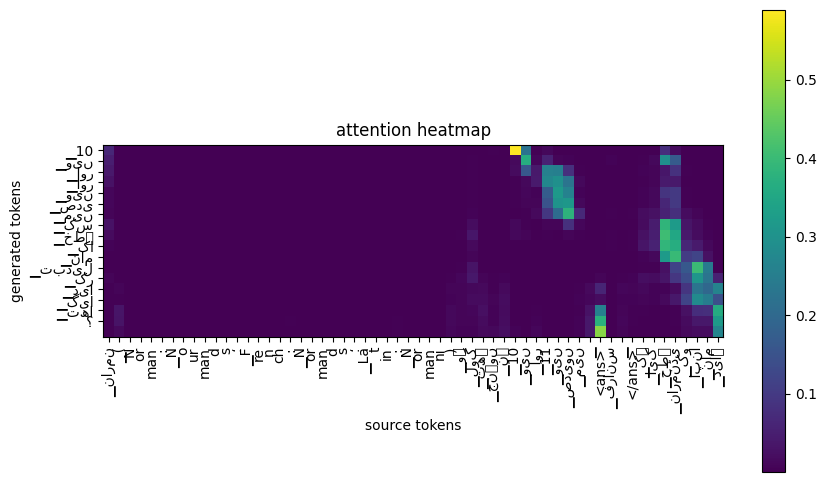

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def greedy_search_with_attention(model, src, src_lens):
    model.eval()
    attentions = []
    with torch.no_grad():
        encoder_outputs, dec_hidden, dec_cell = model.encoder(src, src_lens)
        mask = make_src_mask(src_lens.to(src.device), src.size(1))
        dec_states = (dec_hidden, dec_cell)
        generated_tokens = []
        input_token = torch.tensor([BOS]).unsqueeze(0).to(device)

        for i in range(25):
            output_scores, dec_states, alpha = model.decoder(input_token, dec_states, encoder_outputs, mask)
            best_score = output_scores.argmax(dim=1).item()
            attentions.append(alpha.squeeze().cpu().numpy())
            if best_score == EOS:
                break
            generated_tokens.append(best_score)
            input_token = torch.tensor([[best_score]], device=device)

    return generated_tokens, attentions


sample_src, sample_ref = valid_pairs[0]
src_ids = sp.encode(sample_src)
src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
src_lens = torch.tensor([len(src_ids)])

tokens, attentions = greedy_search_with_attention(model, src_tensor, src_lens)
attn_matrix = np.array(attentions)

src_pieces = sp.encode(sample_src, out_type=str)
out_pieces = [sp.id_to_piece(t) for t in tokens]

plt.figure(figsize=(10, 6))
plt.imshow(attn_matrix[:, :len(src_pieces)], cmap="viridis")
plt.xticks(range(len(src_pieces)), src_pieces, rotation=90)
plt.yticks(range(len(out_pieces)), out_pieces)
plt.xlabel("source tokens")
plt.ylabel("generated tokens")
plt.title("attention heatmap")
plt.colorbar()
plt.savefig("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/attention_heatmap.png")
plt.show()

In [25]:
import pandas as pd

human_eval_path = "/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/human_eval.csv"

df = pd.read_csv(samples_path, sep="\t")
df = df.head(50)

df["fluency_m1"] = ""
df["relevance_m1"] = ""
df["answerability_m1"] = ""
df["fluency_m2"] = ""
df["relevance_m2"] = ""
df["answerability_m2"] = ""

df.to_csv(human_eval_path, index=False)
print("saved to", human_eval_path, "- Both members fill yes/no")

saved to /content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/human_eval.csv - Both members fill yes/no


In [27]:
from sklearn.metrics import cohen_kappa_score

df = pd.read_csv(human_eval_path)

for col in ["fluency", "relevance", "answerability"]:
    m1 = df[col + "_m1"]
    m2 = df[col + "_m2"]

    kappa = cohen_kappa_score(m1, m2)
    print(col, "member1 % yes:", (m1 == "yes").mean() * 100)
    print(col, "member2 % yes:", (m2 == "yes").mean() * 100)
    print(col, "cohen kappa:", kappa)
    print()

fluency member1 % yes: 48.0
fluency member2 % yes: 66.0
fluency cohen kappa: 0.6445497630331753

relevance member1 % yes: 84.0
relevance member2 % yes: 88.0
relevance cohen kappa: 0.6688741721854304

answerability member1 % yes: 56.00000000000001
answerability member2 % yes: 64.0
answerability cohen kappa: 0.6688741721854304



In [ ]:
pip install streamlit torch sentencepiece


   ---------------------------------------- 0.0/413.9 kB ? eta -:--:--
   -- ------------------------------------- 30.7/413.9 kB ? eta -:--:--
   -- ------------------------------------- 30.7/413.9 kB ? eta -:--:--
   ----- --------------------------------- 61.4/413.9 kB 409.6 kB/s eta 0:00:01
   -------- ------------------------------ 92.2/413.9 kB 521.8 kB/s eta 0:00:01
   -------- ------------------------------ 92.2/413.9 kB 521.8 kB/s eta 0:00:01
   ---------------- --------------------- 184.3/413.9 kB 617.3 kB/s eta 0:00:01
   -------------------- ----------------- 225.3/413.9 kB 724.0 kB/s eta 0:00:01
   -------------------------- ----------- 286.7/413.9 kB 707.1 kB/s eta 0:00:01
   -------------------------------------  409.6/413.9 kB 911.8 kB/s eta 0:00:01
   -------------------------------------- 413.9/413.9 kB 889.1 kB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalle

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.40.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
